<a href="https://colab.research.google.com/github/hasinikondle/DataScience_Task/blob/main/DecisionTreeRegressor_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DecisionTreeRegressor

In [40]:
# import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error

In [41]:
# loading file
df = pd.read_csv("cleaned_taxi_trip_pricing.csv")

In [42]:
# display first 5 rows
df.head()

,Unnamed: 0,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Trip_Price_Calculated
0,0,19.350000,2,0,3.0,1,0,3.560000,0.80,0.32,53.82,36.262400,36.262400
1,1,47.590000,0,0,1.0,0,0,3.502989,0.62,0.43,40.57,50.453889,50.453889
2,2,36.870000,1,1,1.0,0,0,2.700000,1.21,0.15,37.27,52.903200,52.903200
3,3,30.330000,1,0,4.0,1,0,3.480000,0.51,0.15,116.81,36.469800,36.469800
4,4,27.070547,1,0,3.0,0,0,2.930000,0.63,0.32,22.64,15.618000,27.229245


In [43]:
# display information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1000 non-null   int64  
 1   Trip_Distance_km       1000 non-null   float64
 2   Time_of_Day            1000 non-null   int64  
 3   Day_of_Week            1000 non-null   int64  
 4   Passenger_Count        1000 non-null   float64
 5   Traffic_Conditions     1000 non-null   int64  
 6   Weather                1000 non-null   int64  
 7   Base_Fare              1000 non-null   float64
 8   Per_Km_Rate            1000 non-null   float64
 9   Per_Minute_Rate        1000 non-null   float64
 10  Trip_Duration_Minutes  1000 non-null   float64
 11  Trip_Price             1000 non-null   float64
 12  Trip_Price_Calculated  1000 non-null   float64
dtypes: float64(8), int64(5)
memory usage: 101.7 KB


Model **Training**

In [44]:
# divide data into input and output
X = df.drop("Trip_Price_Calculated",axis=1)
y = df["Trip_Price_Calculated"]

In [45]:
# split the data for training and testing
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [46]:
# model training
model = DecisionTreeRegressor(max_depth=5)
model.fit(Xtrain,ytrain)

DecisionTreeRegressor(max_depth=5)

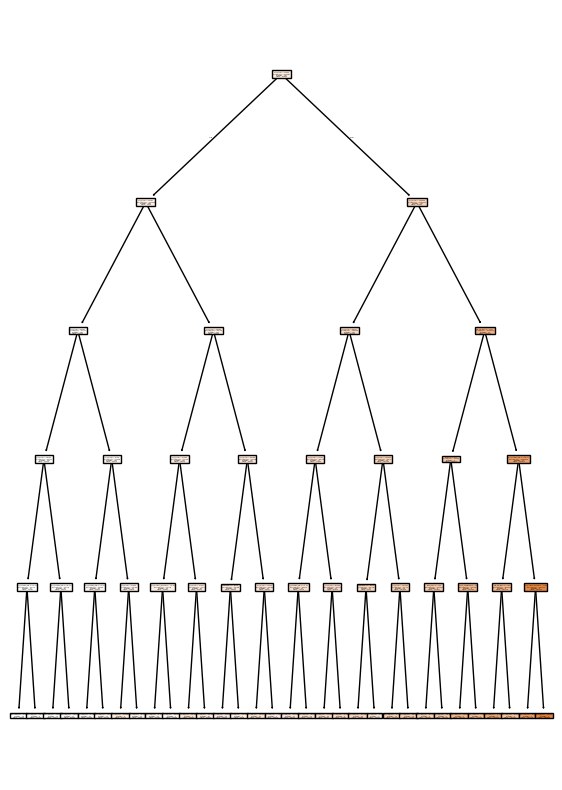

In [47]:
# Tree Classifier
from sklearn.tree import plot_tree
plt.figure(figsize=(7,10))
plot_tree(model,feature_names=df.columns[:-1],filled=True)
plt.show()

**Prediction**

In [48]:
#  prediction
ypred = model.predict(Xtest)
ypred

array([ 80.28715478,  80.28715478,  59.09389415,  80.28715478,
       110.84996718,  51.09175567,  24.27724169,  39.69033038,
        24.27724169,  68.10472691,  66.69743716, 102.72455818,
        68.10472691,  24.27724169,  13.53588124,  13.53588124,
        59.09389415,  33.22635731,  24.27724169,  39.69033038,
        59.09389415,  36.73278481,  13.53588124,  33.22635731,
        36.73278481,  95.46607293,  59.09389415,  45.18419916,
        39.69033038,  80.28715478,  80.28715478,  66.69743716,
        33.22635731,  87.36591703,  59.09389415,  95.46607293,
        24.27724169,  66.69743716,  24.27724169,  80.28715478,
        51.09175567,  33.22635731,  24.27724169,  49.61005   ,
        24.27724169,  51.09175567,  45.18419916,  66.69743716,
        34.05273546,  51.09175567,  59.09389415,  24.27724169,
        51.09175567,  59.09389415,  39.69033038,  59.09389415,
        57.10504463,  31.13339101,  66.69743716,  45.18419916,
        87.36591703,  48.6376    ,  33.22635731,  59.09

In [49]:
# printing r2_score and MAE
print("R2: ",r2_score(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))

R2:  0.9023485456317485
MAE:  4.54056501218132
